In [7]:
# === Setup ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_style("whitegrid")
RNG = 42

# Load data
df_high = pd.read_csv("data/high_popularity_spotify_data.csv")
df_low  = pd.read_csv("data/low_popularity_spotify_data.csv")
df_low  = df_low[df_high.columns]
df = pd.concat([df_high, df_low], ignore_index=True)
print(f"Shape: {df.shape}")
print(f"Genres: {df['playlist_genre'].unique()}")

# Audio features the team agreed to use (numeric, on comparable scales after scaling)
AUDIO_FEATURES = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence",
    "tempo", "duration_ms"
]
TARGET = "playlist_genre"

# Drop rows with missing values in the columns we care about
data = df[AUDIO_FEATURES + [TARGET]].dropna().copy()
print(f"After dropna: {data.shape}")

Shape: (4831, 29)
Genres: ['pop' 'rock' 'jazz' 'classical' 'hip-hop' 'afrobeats' 'latin' 'indian'
 'country' 'r&b' 'electronic' 'soul' 'gaming' 'j-pop' 'metal' 'reggae'
 'k-pop' 'arabic' 'punk' 'blues' 'folk' 'lofi' 'brazilian' 'turkish'
 'ambient' 'korean' 'world' 'indie' 'mandopop' 'cantopop' 'wellness'
 'gospel' 'funk' 'soca' 'disco']
After dropna: (4830, 11)


playlist_genre
electronic    589
pop           515
latin         425
hip-hop       395
ambient       359
rock          345
lofi          298
world         228
arabic        208
brazilian     148
jazz          146
gaming        133
classical     121
blues          88
afrobeats      82
wellness       80
punk           74
turkish        71
folk           68
indian         57
r&b            50
metal          49
soul           44
gospel         39
korean         34
funk           28
cantopop       27
reggae         24
j-pop          23
k-pop          17
indie          17
mandopop       14
soca           14
country        11
disco           9
Name: count, dtype: int64


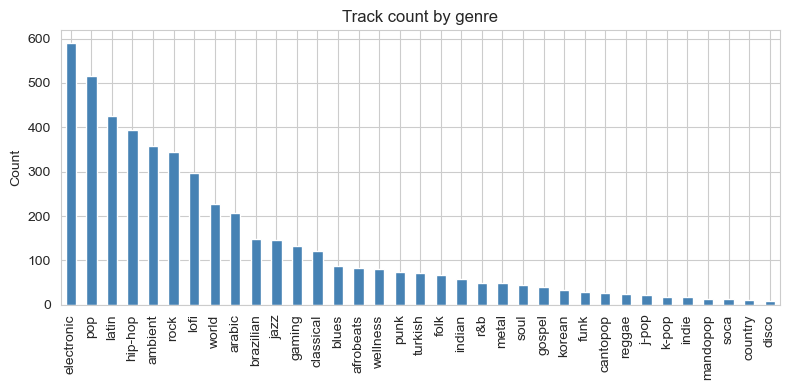

In [8]:
# === EDA 1: Class balance ===
# KNN is sensitive to imbalanced classes (majority class dominates neighborhoods).
# Check this first so we know whether stratified splitting / class weighting matters.
class_counts = data[TARGET].value_counts()
print(class_counts)

fig, ax = plt.subplots(figsize=(8, 4))
class_counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Track count by genre")
ax.set_ylabel("Count"); ax.set_xlabel("")
plt.tight_layout(); plt.show()

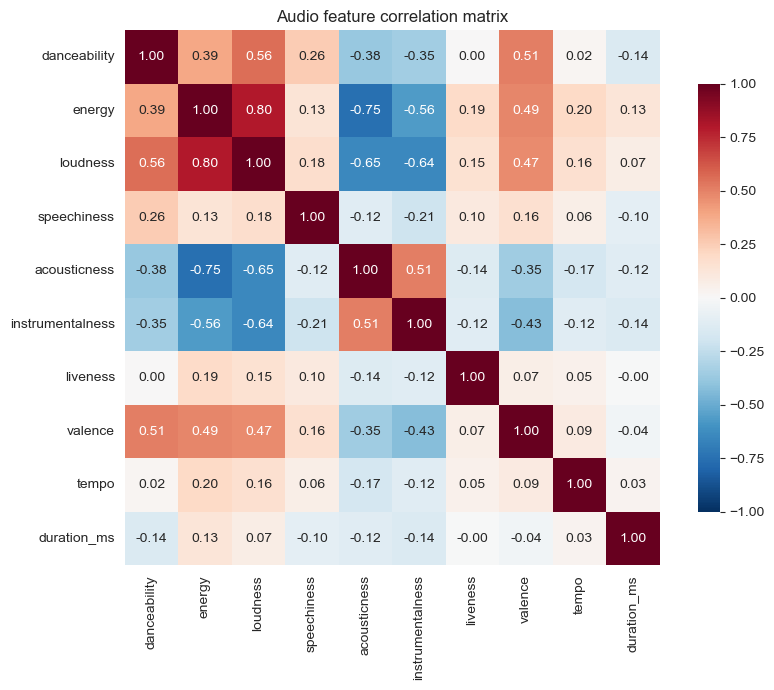

In [9]:
# === EDA 2: Feature correlations ===
# KNN doesn't assume independence, but highly correlated features effectively get
# double-weighted in the distance metric. Worth seeing what's redundant.
corr = data[AUDIO_FEATURES].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Audio feature correlation matrix")
plt.tight_layout(); plt.show()

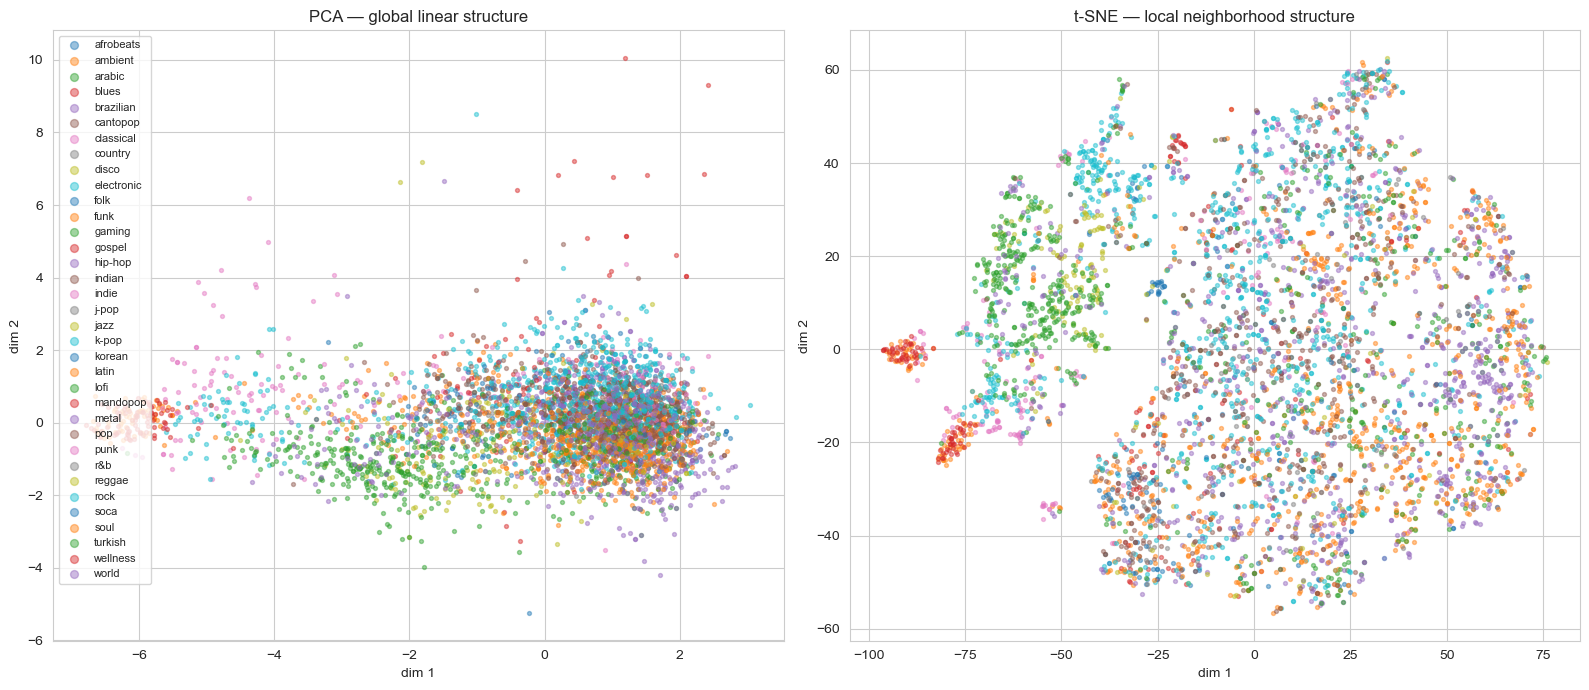

In [10]:
# === EDA 3: 2D projections — global (PCA) and local (t-SNE) structure ===
# PCA: linear, preserves global variance. If genres separate here, even a linear model
#      would work. If they don't, we need something non-linear → motivates KNN.
# t-SNE: non-linear, preserves local neighborhoods. This is closer to what KNN actually
#        exploits — if neighborhoods are genre-coherent in t-SNE, KNN should do well.
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

X_eda = StandardScaler().fit_transform(data[AUDIO_FEATURES])

# Subsample for t-SNE — it's O(n²) and slow above ~10k points.
# Stratified subsample keeps genre proportions intact.
SUBSAMPLE_N = 5000
if len(data) > SUBSAMPLE_N:
    idx = (data.groupby(TARGET, group_keys=False)
               .apply(lambda g: g.sample(min(len(g), SUBSAMPLE_N // data[TARGET].nunique()),
                                         random_state=RNG))
               .index)
    X_sub = X_eda[data.index.get_indexer(idx)]
    y_sub = data.loc[idx, TARGET].values
else:
    X_sub, y_sub = X_eda, data[TARGET].values

pcs   = PCA(n_components=2, random_state=RNG).fit_transform(X_sub)
tsne  = TSNE(n_components=2, perplexity=30, init="pca",
             learning_rate="auto", random_state=RNG, n_jobs=-1).fit_transform(X_sub)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, coords, title in [(axes[0], pcs,  "PCA — global linear structure"),
                          (axes[1], tsne, "t-SNE — local neighborhood structure")]:
    for g in np.unique(y_sub):
        mask = (y_sub == g)
        ax.scatter(coords[mask, 0], coords[mask, 1], s=8, alpha=0.45, label=g)
    ax.set_title(title); ax.set_xlabel("dim 1"); ax.set_ylabel("dim 2")
axes[0].legend(markerscale=2, fontsize=8)
plt.tight_layout(); plt.show()

In [11]:
# ============================================================
# BLOCK 1: DATA CLEANING + PREPARATION
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# df already loaded and merged in Setup cell

# --- Dedup on track_id ---
before = len(df)
df = df.drop_duplicates(subset="track_id", keep="first").reset_index(drop=True)
print(f"After dedup: {df.shape}  (removed {before - len(df)})")

# --- Cleaning Move 1: bucket genres into 4 acoustic families ---
GENRE_BUCKETS = {
    # Acoustic / Instrumental
    "classical":  "acoustic_instrumental",
    "jazz":       "acoustic_instrumental",
    "lofi":       "acoustic_instrumental",
    "ambient":    "acoustic_instrumental",
    "folk":       "acoustic_instrumental",
    # Vocal / Popular
    "pop":        "vocal_popular",
    "rock":       "vocal_popular",
    "punk":       "vocal_popular",
    "indie":      "vocal_popular",
    "blues":      "vocal_popular",
    "metal":      "vocal_popular",
    # Rhythm / Urban
    "hip-hop":    "rhythm_urban",
    "r&b":        "rhythm_urban",
    "soul":       "rhythm_urban",
    "electronic": "rhythm_urban",
    "gaming":     "rhythm_urban",
    "k-pop":      "rhythm_urban",
    "j-pop":      "rhythm_urban",
    # International / World
    "arabic":     "international",
    "brazilian":  "international",
    "latin":      "international",
    "world":      "international",
    "afrobeats":  "international",
    "reggae":     "international",
    "indian":     "international",
    "korean":     "international",
    "turkish":    "international",
}
df["genre_clean"] = df["playlist_genre"].map(GENRE_BUCKETS)

unmapped = df.loc[df["genre_clean"].isna(), "playlist_genre"].value_counts()
if len(unmapped) > 0:
    print("\nUnmapped genres (dropped):")
    print(unmapped.to_string())
    df = df.dropna(subset=["genre_clean"]).copy()

print("\nAfter bucket collapse:")
print(df["genre_clean"].value_counts().to_string())

# --- Cleaning Move 2: drop unusual time signatures + spoken-word outliers ---
before = len(df)
df = df[
    (df["time_signature"].isin([3, 4])) &
    (df["speechiness"] < 0.66)
].copy()
print(f"\nAfter outlier filter: {before} → {len(df)} rows "
      f"({100*(before-len(df))/before:.1f}% dropped)")

# --- Final feature/target selection ---
AUDIO_FEATURES = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence",
    "tempo", "duration_ms",
]
TARGET = "genre_clean"

data_model = df[AUDIO_FEATURES + [TARGET]].dropna().copy()
print(f"\nFinal modeling rows: {len(data_model)}")
print(f"Class balance ratio (max/min): "
      f"{data_model[TARGET].value_counts().max() / data_model[TARGET].value_counts().min():.1f}x")

# --- 80/20 stratified split + scale ---
X = data_model[AUDIO_FEATURES].values
y = data_model[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RNG, stratify=y
)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

le = LabelEncoder().fit(y_train)
y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)

print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")
print(f"Classes: {list(le.classes_)}")

After dedup: (4495, 29)  (removed 336)

Unmapped genres (dropped):
playlist_genre
wellness    80
gospel      34
funk        28
cantopop    27
mandopop    14
soca        14
country     11
disco        9

After bucket collapse:
genre_clean
international            1213
rhythm_urban             1157
vocal_popular             963
acoustic_instrumental     945

After outlier filter: 4278 → 4114 rows (3.8% dropped)

Final modeling rows: 4114
Class balance ratio (max/min): 1.4x

Train: (3291, 10), Test: (823, 10)
Classes: ['acoustic_instrumental', 'international', 'rhythm_urban', 'vocal_popular']


k=  1  CV accuracy = 0.4853  (+/- 0.0137)
k=  3  CV accuracy = 0.5141  (+/- 0.0083)
k=  5  CV accuracy = 0.5503  (+/- 0.0171)
k=  7  CV accuracy = 0.5500  (+/- 0.0183)
k= 11  CV accuracy = 0.5542  (+/- 0.0181)
k= 15  CV accuracy = 0.5603  (+/- 0.0150)
k= 21  CV accuracy = 0.5655  (+/- 0.0191)
k= 31  CV accuracy = 0.5661  (+/- 0.0096)
k= 51  CV accuracy = 0.5631  (+/- 0.0141)
k= 75  CV accuracy = 0.5634  (+/- 0.0115)
k=101  CV accuracy = 0.5573  (+/- 0.0144)

Best k by CV: 31


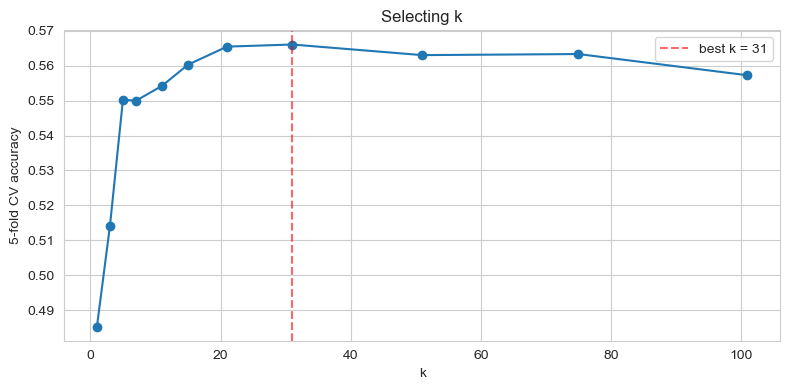

In [12]:
# === Choose k via 5-fold CV on the training set ===
# Reporting CV here, not test set, to avoid peeking at test data when picking k.
ks = [1, 3, 5, 7, 11, 15, 21, 31, 51, 75, 101]
cv_scores = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)

for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k, weights="distance", n_jobs=-1)
    s = cross_val_score(knn, X_train_s, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
    cv_scores.append(s.mean())
    print(f"k={k:3d}  CV accuracy = {s.mean():.4f}  (+/- {s.std():.4f})")

best_k = ks[int(np.argmax(cv_scores))]
print(f"\nBest k by CV: {best_k}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ks, cv_scores, marker="o")
ax.axvline(best_k, ls="--", color="red", alpha=0.6, label=f"best k = {best_k}")
ax.set_xlabel("k"); ax.set_ylabel("5-fold CV accuracy")
ax.set_title("Selecting k"); ax.legend()
plt.tight_layout(); plt.show()

In [13]:
# ============================================================
# BLOCK 2: MODEL DEFINITION + FITTING
# ============================================================
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Each entry just records (a) the fitted model and (b) which X variant it needs.
# y is ALWAYS the canonical y_train / y_test from Block 1 (string labels), except
# XGBoost which we handle explicitly in Block 3 by encoding/decoding inline.
MODEL_SPECS = {
    "KNN": {
        "estimator": KNeighborsClassifier(n_neighbors=11, weights="distance", n_jobs=-1),
        "scaled":    True,
    },
    "Logistic Regression": {
        "estimator": LogisticRegression(
            max_iter=2000, class_weight="balanced", n_jobs=-1, random_state=RNG
        ),
        "scaled":    True,
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(
            n_estimators=500, max_features="sqrt", class_weight="balanced",
            n_jobs=-1, random_state=RNG
        ),
        "scaled":    False,
    },
    "XGBoost": {
        "estimator": XGBClassifier(
            n_estimators=500, max_depth=6, learning_rate=0.1,
            subsample=0.9, colsample_bytree=0.9,
            objective="multi:softprob", eval_metric="mlogloss",
            n_jobs=-1, random_state=RNG, tree_method="hist",
        ),
        "scaled":    False,
    },
}

def get_X_train(spec): return X_train_s if spec["scaled"] else X_train
def get_X_test(spec):  return X_test_s  if spec["scaled"] else X_test
def get_y_train(name): return y_train_enc if name == "XGBoost" else y_train
def get_y_test(name):  return y_test_enc  if name == "XGBoost" else y_test

fitted = {}
for name, spec in MODEL_SPECS.items():
    print(f"Fitting {name}...")
    spec["estimator"].fit(get_X_train(spec), get_y_train(name))
    fitted[name] = spec["estimator"]
print("All models fit.")

Fitting KNN...
Fitting Logistic Regression...
Fitting Random Forest...
Fitting XGBoost...
All models fit.


              Model  Train acc  Test acc  Test error  Gen. gap  CV acc (mean)  CV acc (std)  Macro F1  Weighted F1  Log loss
                KNN     0.9991    0.5650      0.4350    0.4341         0.5542        0.0181    0.5738       0.5660    2.5565
Logistic Regression     0.5427    0.5674      0.4326   -0.0247         0.5360        0.0115    0.5749       0.5643    1.0550
      Random Forest     0.9991    0.6100      0.3900    0.3891         0.5950        0.0113    0.6175       0.6108    0.9415
            XGBoost     0.9991    0.5881      0.4119    0.4110         0.5737        0.0254    0.5964       0.5889    1.1219


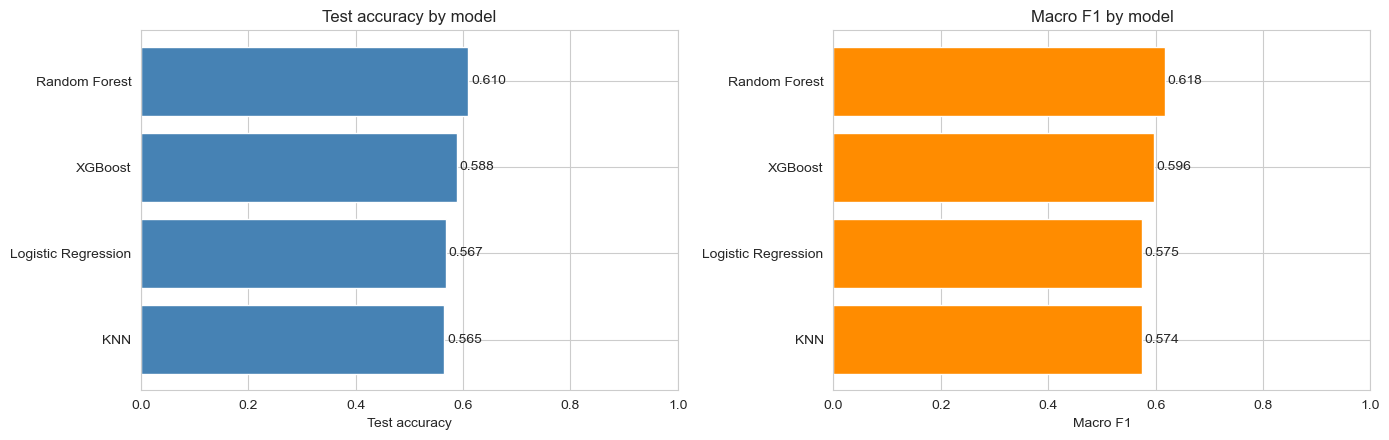

Best model by test accuracy: Random Forest  (test acc = 0.610)


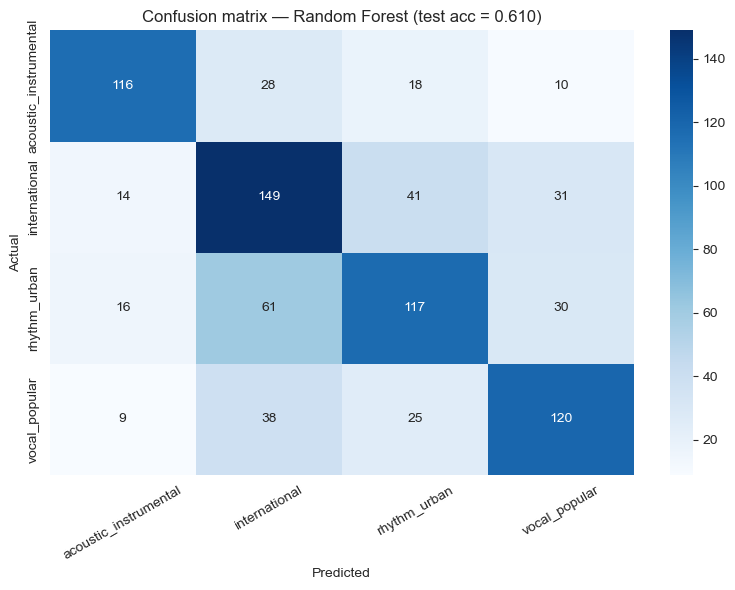


Classification report — Random Forest:
                       precision    recall  f1-score   support

acoustic_instrumental      0.748     0.674     0.709       172
        international      0.540     0.634     0.583       235
         rhythm_urban      0.582     0.522     0.551       224
        vocal_popular      0.628     0.625     0.627       192

             accuracy                          0.610       823
            macro avg      0.625     0.614     0.617       823
         weighted avg      0.616     0.610     0.611       823



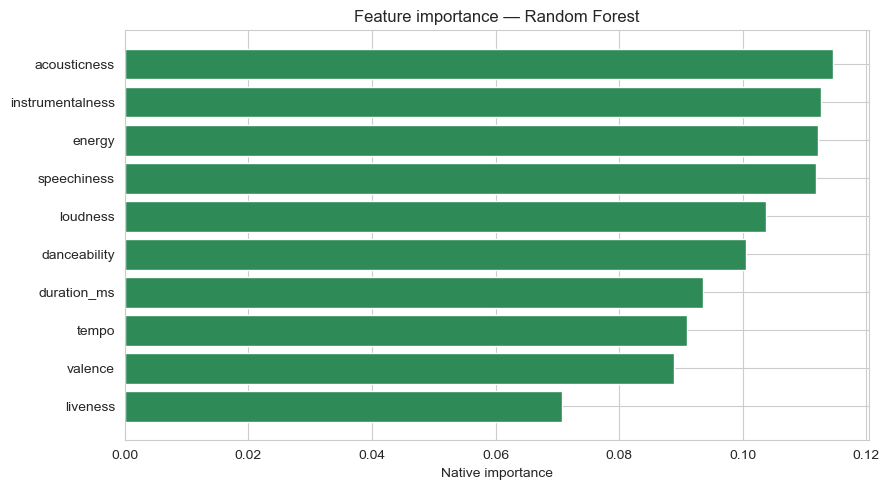

         feature  importance
    acousticness    0.114660
instrumentalness    0.112730
          energy    0.112133
     speechiness    0.111846
        loudness    0.103827
    danceability    0.100565
     duration_ms    0.093557
           tempo    0.091057
         valence    0.088894
        liveness    0.070732


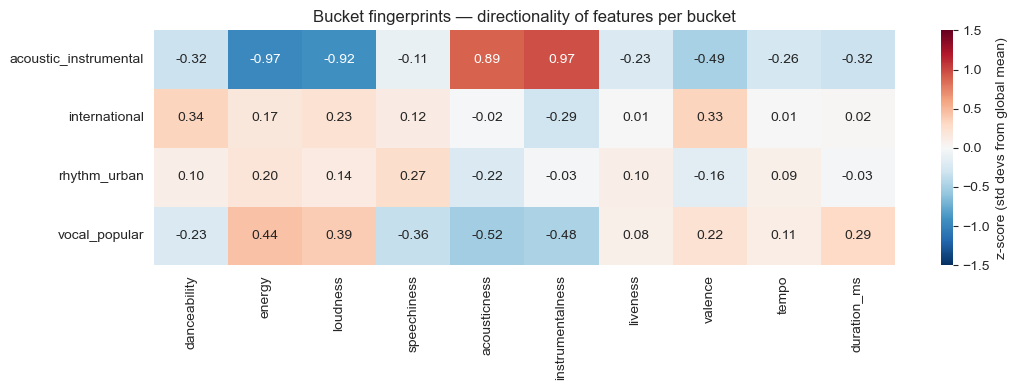

In [14]:
# ============================================================
# BLOCK 3: EVALUATION + VISUALIZATION
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, log_loss,
                             classification_report, confusion_matrix)
from sklearn.inspection import permutation_importance

# --- Helpers: always return STRING labels regardless of model ---
def predict_labels(name, X):
    """Predict and return string labels, decoding XGBoost's int output if needed."""
    raw = fitted[name].predict(X)
    return le.inverse_transform(raw) if name == "XGBoost" else raw

def predict_proba(name, X):
    return fitted[name].predict_proba(X)

# --- Build results table from canonical Block 1 variables only ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
results = []

for name, spec in MODEL_SPECS.items():
    Xtr, Xte = get_X_train(spec), get_X_test(spec)
    ytr_str, yte_str = y_train, y_test                  # strings, for metric reporting
    ytr_fit = get_y_train(name)                          # whatever the model was fit on

    y_tr_pred  = predict_labels(name, Xtr)
    y_te_pred  = predict_labels(name, Xte)
    y_te_proba = predict_proba(name, Xte)

    # CV uses whatever target form the model was fit on (XGB needs ints)
    cv_scores = cross_val_score(fitted[name], Xtr, ytr_fit,
                                cv=cv, scoring="accuracy", n_jobs=-1)

    train_acc = accuracy_score(ytr_str, y_tr_pred)
    test_acc  = accuracy_score(yte_str, y_te_pred)
    # log_loss needs label order matched between proba columns and y_true
    proba_classes = (le.classes_ if name == "XGBoost"
                     else fitted[name].classes_)

    results.append({
        "Model":         name,
        "Train acc":     round(train_acc, 4),
        "Test acc":      round(test_acc, 4),
        "Test error":    round(1 - test_acc, 4),
        "Gen. gap":      round(train_acc - test_acc, 4),
        "CV acc (mean)": round(cv_scores.mean(), 4),
        "CV acc (std)":  round(cv_scores.std(), 4),
        "Macro F1":      round(f1_score(yte_str, y_te_pred, average="macro"), 4),
        "Weighted F1":   round(f1_score(yte_str, y_te_pred, average="weighted"), 4),
        "Log loss":      round(log_loss(yte_str, y_te_proba, labels=list(proba_classes)), 4),
    })

results_df = pd.DataFrame(results)
print("="*100)
print(results_df.to_string(index=False))
# === Bar chart: test accuracy + macro F1 across all four models ===
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

order = results_df.sort_values("Test acc", ascending=True)
axes[0].barh(order["Model"], order["Test acc"], color="steelblue")
axes[0].set_xlabel("Test accuracy"); axes[0].set_title("Test accuracy by model")
axes[0].set_xlim(0, 1)
for i, v in enumerate(order["Test acc"]):
    axes[0].text(v + 0.005, i, f"{v:.3f}", va="center")

order2 = results_df.sort_values("Macro F1", ascending=True)
axes[1].barh(order2["Model"], order2["Macro F1"], color="darkorange")
axes[1].set_xlabel("Macro F1"); axes[1].set_title("Macro F1 by model")
axes[1].set_xlim(0, 1)
for i, v in enumerate(order2["Macro F1"]):
    axes[1].text(v + 0.005, i, f"{v:.3f}", va="center")
plt.tight_layout(); plt.show()
# === Confusion matrix — best model only ===
best_name  = results_df.loc[results_df["Test acc"].idxmax(), "Model"]
best_spec  = MODEL_SPECS[best_name]
best_test_acc = results_df.loc[results_df["Model"] == best_name, "Test acc"].values[0]
print(f"Best model by test accuracy: {best_name}  (test acc = {best_test_acc:.3f})")

y_pred_best = predict_labels(best_name, get_X_test(best_spec))
present_labels = sorted(set(y_test) | set(y_pred_best))
cm = confusion_matrix(y_test, y_pred_best, labels=present_labels)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=present_labels, yticklabels=present_labels, ax=ax, cbar=True)
ax.set_title(f"Confusion matrix — {best_name} (test acc = {best_test_acc:.3f})")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

print(f"\nClassification report — {best_name}:")
print(classification_report(y_test, y_pred_best, labels=present_labels, digits=3))
# === Feature importance — best model only ===
best_model = fitted[best_name]

if hasattr(best_model, "feature_importances_"):
    imp = best_model.feature_importances_
    imp_label = "Native importance"
elif hasattr(best_model, "coef_"):
    imp = np.abs(best_model.coef_).mean(axis=0)
    imp = imp / imp.sum()
    imp_label = "|Coefficient| (normalized)"
else:
    print("Computing permutation importance (slow)...")
    perm = permutation_importance(
        best_model, get_X_test(best_spec), get_y_test(best_name),
        n_repeats=10, random_state=RNG, n_jobs=-1, scoring="accuracy"
    )
    imp = perm.importances_mean
    imp_label = "Permutation importance (drop in test acc)"

imp_df = (pd.DataFrame({"feature": AUDIO_FEATURES, "importance": imp})
            .sort_values("importance", ascending=True))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(imp_df["feature"], imp_df["importance"], color="seagreen")
ax.set_xlabel(imp_label)
ax.set_title(f"Feature importance — {best_name}")
plt.tight_layout(); plt.show()
print(imp_df.sort_values("importance", ascending=False).to_string(index=False))
# === Bucket fingerprints — directionality of features per bucket ===
X_train_s_df = pd.DataFrame(X_train_s, columns=AUDIO_FEATURES)
X_train_s_df[TARGET] = y_train
bucket_profile = X_train_s_df.groupby(TARGET).mean()

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(bucket_profile, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1.5, vmax=1.5, ax=ax,
            cbar_kws={"label": "z-score (std devs from global mean)"})
ax.set_title("Bucket fingerprints — directionality of features per bucket")
ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout(); plt.show()